# Transporte óptimo en dimensión uno

Este cuaderno acompaña el **Capítulo 8** de las notas del curso (*Transporte óptimo en dimensión uno*). Exploraremos computacionalmente sus conceptos centrales:

- La **función de distribución acumulada** (FDA) y su **pseudoinversa**.
- La construcción del **mapa de transporte monótono** $T_{\mathrm{mon}} = F_\nu^{[-1]} \circ F_\mu$.
- La **optimalidad** del plan comonótono: comparación con planes aleatorios.
- La **fórmula del costo óptimo** en términos de las pseudoinversas.

Utilizaremos la biblioteca [POT](https://pythonot.github.io/) para verificar los resultados numéricos contra el solver exacto. Los **ejercicios computacionales** están al final; sus enunciados figuran también en la sección de ejercicios del Capítulo 8 de las notas.

In [ ]:
# @title
pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 32.6 MB/s eta 0:00:00


In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
import ot
from scipy.stats import norm

## 1. La función de distribución acumulada y su pseudoinversa

Dada una medida de probabilidad $\mu$ sobre $\mathbb{R}$, su **función de distribución acumulada** es

$$
F_\mu(x) = \mu((-\infty, x]).
$$

Su **pseudoinversa** está definida para $t \in (0,1)$ por

$$
F_\mu^{[-1]}(t) = \inf\{x \in \mathbb{R} : F_\mu(x) \geq t\}.
$$

Ilustramos estas nociones en los tres casos típicos: medida absolutamente continua, medida discreta y medida mixta.

### Ejemplo 1: medida absolutamente continua

Tomamos $\mu = U[0,2]$, la medida uniforme sobre $[0,2]$.

$$
F_\mu(x) = \begin{cases} 0 & x < 0 \\ x/2 & 0 \leq x \leq 2 \\ 1 & x > 2 \end{cases}
\qquad
F_\mu^{[-1]}(t) = 2t, \quad t \in (0,1).
$$

En este caso la pseudoinversa coincide con la inversa usual, ya que $F_\mu$ es estrictamente creciente y continua.

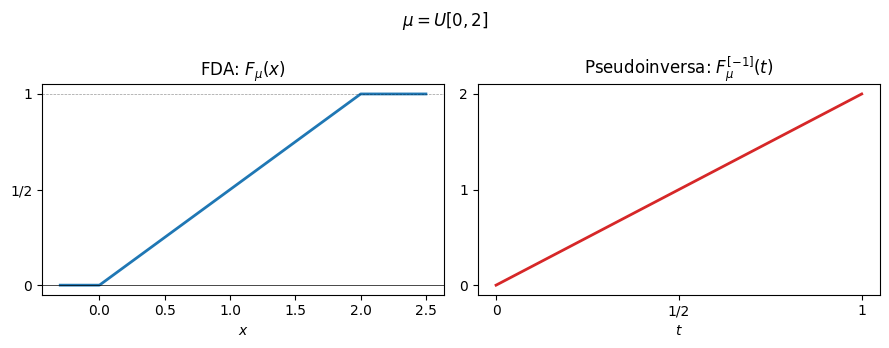

In [ ]:
# @title
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))

x = np.linspace(-0.3, 2.5, 500)
F = np.clip(x / 2, 0, 1)

t = np.linspace(0, 1, 500)
Finv = 2 * t

axs[0].plot(x, F, lw=2, color="tab:blue")
axs[0].set_title(r"FDA: $F_\mu(x)$")
axs[0].set_xlabel("$x$")
axs[0].axhline(0, color="k", lw=0.5)
axs[0].axhline(1, color="k", lw=0.5, ls="--", alpha=0.4)
axs[0].set_yticks([0, 0.5, 1])
axs[0].set_yticklabels(["0", "1/2", "1"])

axs[1].plot(t, Finv, lw=2, color="tab:red")
axs[1].set_title(r"Pseudoinversa: $F_\mu^{[-1]}(t)$")
axs[1].set_xlabel("$t$")
axs[1].set_yticks([0, 1, 2])
axs[1].set_xticks([0, 0.5, 1])
axs[1].set_xticklabels(["0", "1/2", "1"])

plt.suptitle(r"$\mu = U[0,2]$")
plt.tight_layout()
plt.show()

### Ejemplo 2: medida discreta

Tomamos $\mu = \tfrac{1}{3}\delta_0 + \tfrac{1}{3}\delta_1 + \tfrac{1}{3}\delta_2$.

La FDA es una función escalera con saltos en $0, 1, 2$, y la pseudoinversa es constante en intervalos de longitud $1/3$:

$$
F_\mu^{[-1]}(t) = \begin{cases} 0 & t \in (0, 1/3] \\ 1 & t \in (1/3, 2/3] \\ 2 & t \in (2/3, 1) \end{cases}
$$

Obsérvese la simetría: los **saltos** de $F_\mu$ corresponden a los **tramos planos** de $F_\mu^{[-1]}$, y viceversa.

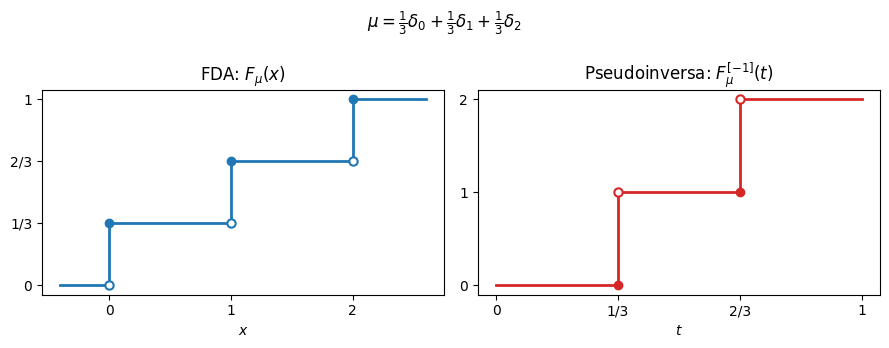

In [ ]:
# @title
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))

# FDA: función escalera, continua por la derecha
xs = [-0.4, 0, 0, 1, 1, 2, 2, 2.6]
Fs = [0,    0, 1/3, 1/3, 2/3, 2/3, 1, 1]

axs[0].plot(xs, Fs, lw=2, color="tab:blue", drawstyle="steps-post")
# círculos abiertos/cerrados en los saltos
for x0, y_low, y_high in [(0, 0, 1/3), (1, 1/3, 2/3), (2, 2/3, 1)]:
    axs[0].plot(x0, y_high, "o", color="tab:blue", ms=6)
    axs[0].plot(x0, y_low,  "o", color="tab:blue", ms=6,
                markerfacecolor="white", markeredgewidth=1.5)
axs[0].set_title(r"FDA: $F_\mu(x)$")
axs[0].set_xlabel("$x$")
axs[0].set_yticks([0, 1/3, 2/3, 1])
axs[0].set_yticklabels(["0", "1/3", "2/3", "1"])
axs[0].set_xticks([0, 1, 2])

# Pseudoinversa: constante en intervalos
ts = [0, 1/3, 1/3, 2/3, 2/3, 1]
Fs_inv = [0, 0,   1,   1,   2,  2]

axs[1].plot(ts, Fs_inv, lw=2, color="tab:red", drawstyle="steps-post")
for t0, y_low, y_high in [(1/3, 0, 1), (2/3, 1, 2)]:
    axs[1].plot(t0, y_high, "o", color="tab:red", ms=6,
                markerfacecolor="white", markeredgewidth=1.5)
    axs[1].plot(t0, y_low,  "o", color="tab:red", ms=6)
axs[1].set_title(r"Pseudoinversa: $F_\mu^{[-1]}(t)$")
axs[1].set_xlabel("$t$")
axs[1].set_xticks([0, 1/3, 2/3, 1])
axs[1].set_xticklabels(["0", "1/3", "2/3", "1"])
axs[1].set_yticks([0, 1, 2])

plt.suptitle(r"$\mu = \frac{1}{3}\delta_0 + \frac{1}{3}\delta_1 + \frac{1}{3}\delta_2$")
plt.tight_layout()
plt.show()

### Ejemplo 3: medida mixta

Tomamos $\mu = \tfrac{1}{2}U[0,1] + \tfrac{1}{2}\delta_2$.

$$
F_\mu(x) = \begin{cases} 0 & x < 0 \\ x/2 & 0 \leq x < 1 \\ 1/2 & 1 \leq x < 2 \\ 1 & x \geq 2 \end{cases}
\qquad
F_\mu^{[-1]}(t) = \begin{cases} 2t & t \in (0, 1/2) \\ 2 & t \in [1/2, 1) \end{cases}
$$

El tramo plano de $F_\mu$ en $[1,2)$ (donde $\mu$ no tiene masa) produce un salto en $F_\mu^{[-1]}$ en $t = 1/2$.

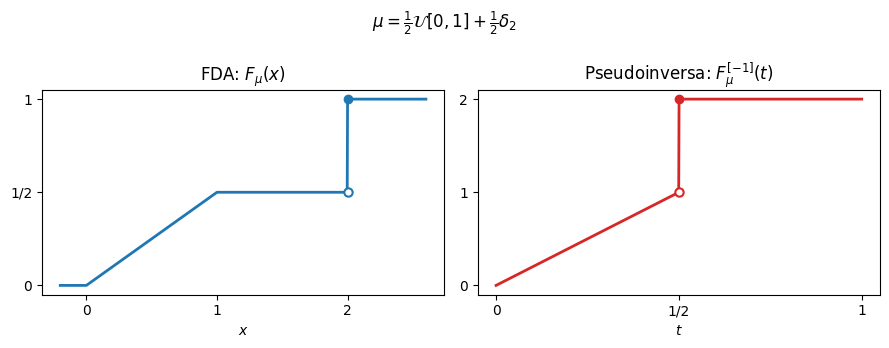

In [ ]:
# @title
fig, axs = plt.subplots(1, 2, figsize=(9, 3.5))

x = np.linspace(-0.2, 2.6, 1000)
F = np.where(x < 0, 0,
    np.where(x < 1, x/2,
    np.where(x < 2, 0.5, 1.0)))

axs[0].plot(x, F, lw=2, color="tab:blue")
axs[0].plot(2, 1,   "o", color="tab:blue", ms=6)
axs[0].plot(2, 0.5, "o", color="tab:blue", ms=6,
            markerfacecolor="white", markeredgewidth=1.5)
axs[0].set_title(r"FDA: $F_\mu(x)$")
axs[0].set_xlabel("$x$")
axs[0].set_yticks([0, 0.5, 1])
axs[0].set_yticklabels(["0", "1/2", "1"])
axs[0].set_xticks([0, 1, 2])

t = np.linspace(0, 1, 1000)
Finv = np.where(t < 0.5, 2*t, 2.0)

axs[1].plot(t, Finv, lw=2, color="tab:red")
axs[1].plot(0.5, 2, "o", color="tab:red", ms=6)
axs[1].plot(0.5, 1, "o", color="tab:red", ms=6,
            markerfacecolor="white", markeredgewidth=1.5)
axs[1].set_title(r"Pseudoinversa: $F_\mu^{[-1]}(t)$")
axs[1].set_xlabel("$t$")
axs[1].set_xticks([0, 0.5, 1])
axs[1].set_xticklabels(["0", "1/2", "1"])
axs[1].set_yticks([0, 1, 2])

plt.suptitle(r"$\mu = \frac{1}{2}\mathcal{U}[0,1] + \frac{1}{2}\delta_2$")
plt.tight_layout()
plt.show()

## 2. El mapa de transporte monótono

Dadas $\mu, \nu \in P(\mathbb{R})$ con $\mu$ sin átomos, el **mapa de transporte monótono** está dado por

$$
T_{\mathrm{mon}}(x) = F_\nu^{[-1]}(F_\mu(x)).
$$

Es el único (salvo un conjunto $\mu$-nulo) mapa medible no decreciente que transporta $\mu$ en $\nu$ (Teorema 8.2.1).

En el siguiente ejemplo tomamos:
- $\mu = N(0,1)$, la distribución normal estándar.
- $\nu = N(3, 0.5^2)$, una normal desplazada y más concentrada.

El mapa monótono comprime y desplaza la distribución de $\mu$ hacia $\nu$.

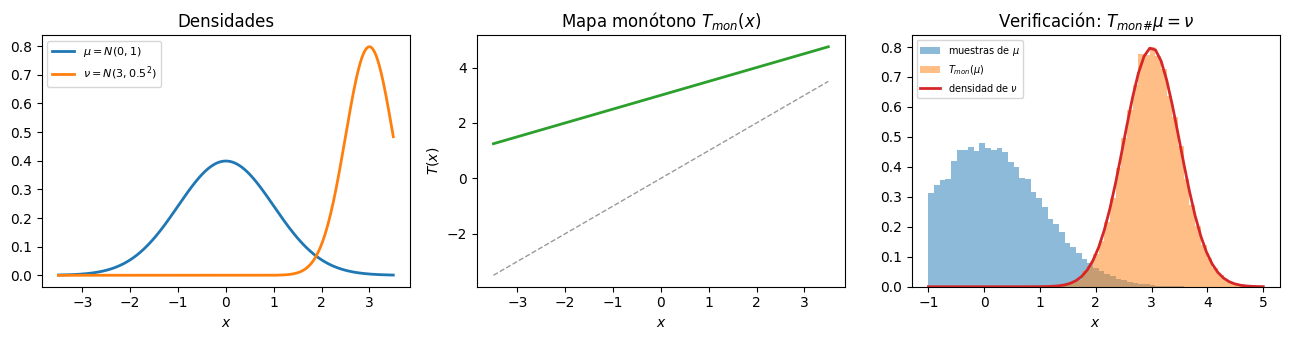

In [ ]:
# @title
from scipy.stats import norm

mu_mean, mu_std = 0.0, 1.0
nu_mean, nu_std = 3.0, 0.5

# Mapa monótono: T(x) = F_nu^{-1}(F_mu(x))
def T_mon(x):
    return norm.ppf(norm.cdf(x, mu_mean, mu_std), nu_mean, nu_std)

x = np.linspace(-3.5, 3.5, 500)

fig, axs = plt.subplots(1, 3, figsize=(13, 3.5))

# Densidades
axs[0].plot(x, norm.pdf(x, mu_mean, mu_std), lw=2, label=r"$\mu = N(0,1)$")
axs[0].plot(x, norm.pdf(x, nu_mean, nu_std), lw=2, label=r"$\nu = N(3, 0.5^2)$")
axs[0].set_title("Densidades")
axs[0].legend(fontsize=8)
axs[0].set_xlabel("$x$")

# Mapa monótono
axs[1].plot(x, T_mon(x), lw=2, color="tab:green")
axs[1].plot(x, x, "k--", alpha=0.4, lw=1)
axs[1].set_title(r"Mapa monótono $T_{mon}(x)$")
axs[1].set_xlabel("$x$")
axs[1].set_ylabel("$T(x)$")

# Verificación: imagen de mu bajo T debe ser nu
samples_mu = np.random.normal(mu_mean, mu_std, 50000)
samples_T  = T_mon(samples_mu)

bins = np.linspace(-1, 5, 60)
axs[2].hist(samples_mu, bins=bins, density=True, alpha=0.5, label=r"muestras de $\mu$")
axs[2].hist(samples_T,  bins=bins, density=True, alpha=0.5, label=r"$T_{mon}(\mu)$")
axs[2].plot(bins, norm.pdf(bins, nu_mean, nu_std), lw=2, color="tab:red",
            label=r"densidad de $\nu$")
axs[2].set_title(r"Verificación: $T_{mon\#}\mu = \nu$")
axs[2].legend(fontsize=7)
axs[2].set_xlabel("$x$")

plt.tight_layout()
plt.show()

## 3. Optimalidad del mapa monótono

El plan comonótono $\gamma_{\mathrm{mon}} = (\mathrm{id}, T_{\mathrm{mon}})_{\#} \mu$ es óptimo para el costo cuadrático, y más en general para cualquier costo de la forma $h(y-x)$ con $h$ convexa; si $h$ es estrictamente convexa es además el **único** plan óptimo (Teorema 8.4.1).

Para verificarlo numéricamente, discretizamos $\mu$ y $\nu$ en medidas empíricas con $n$ puntos, calculamos el plan óptimo mediante `ot.emd`, y comparamos su costo con el del plan inducido por el mapa monótono y con el de planes generados aleatoriamente.

Costo plan monótono:  9.705167
Costo plan óptimo:    9.705167
Costo promedio aleatorio: 10.616252
Costo mínimo aleatorio:   10.461813


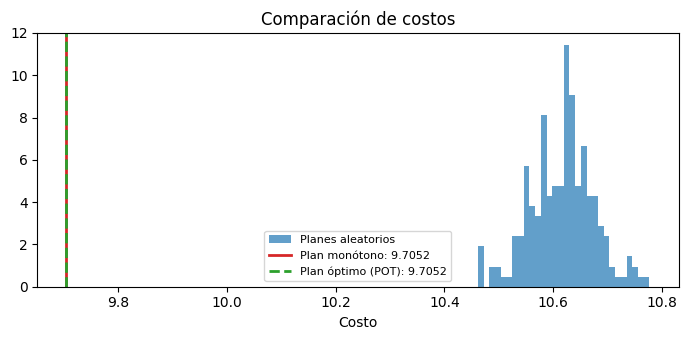

In [ ]:
# @title
np.random.seed(42)
n = 200

# Muestras de mu y nu, ordenadas para construir el mapa monótono discreto
samples_mu = np.sort(np.random.normal(mu_mean, mu_std, n))
samples_nu = np.sort(np.random.normal(nu_mean, nu_std, n))

a = np.ones(n) / n
b = np.ones(n) / n

C = (samples_mu[:, None] - samples_nu[None, :]) ** 2

# Plan óptimo via POT
pi_opt = ot.emd(a, b, C)
cost_opt = np.sum(pi_opt * C)

# El plan devuelto por POT es exactamente el monótono: con pesos iguales y muestras
# ordenadas, es la matriz identidad / n  (soporte sin cruces, Proposición 8.2.3)
print(f"Distancia entre el plan de POT y el plan monótono: {np.max(np.abs(pi_opt - np.eye(n)/n)):.2e}")

# Plan monótono: empareja samples_mu[i] con samples_nu[i] (ambos ordenados)
cost_mon = np.mean((samples_mu - samples_nu) ** 2)

# Planes aleatorios
n_random = 200
costs_random = []
for _ in range(n_random):
    sigma = np.random.permutation(n)
    costs_random.append(np.mean((samples_mu - samples_nu[sigma]) ** 2))

print(f"Costo plan monótono:  {cost_mon:.6f}")
print(f"Costo plan óptimo:    {cost_opt:.6f}")
print(f"Costo promedio aleatorio: {np.mean(costs_random):.6f}")
print(f"Costo mínimo aleatorio:   {np.min(costs_random):.6f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(costs_random, bins=30, density=True, alpha=0.7, label="Planes aleatorios")
ax.axvline(cost_mon, color="tab:red",   lw=2, label=f"Plan monótono: {cost_mon:.4f}")
ax.axvline(cost_opt, color="tab:green", lw=2, ls="--",
           label=f"Plan óptimo (POT): {cost_opt:.4f}")
ax.set_xlabel("Costo")
ax.set_title("Comparación de costos")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. El plan comonótono cuando $\mu$ tiene átomos

Cuando $\mu$ tiene átomos el mapa monótono puede no existir: la masa concentrada en un punto no puede dividirse mediante un mapa. Sin embargo, el **plan comonótono**

$$
\gamma_{\mathrm{mon}} = \bigl(F_\mu^{[-1]}, F_\nu^{[-1]}\bigr)_\# \mathcal{L}^1|_{(0,1)}
$$

siempre está definido, y sigue siendo óptimo para costos $h(y-x)$ con $h$ convexa.

Para medidas discretas, $\gamma_{\mathrm{mon}}$ se calcula exactamente recorriendo $t\in(0,1)$ y anotando en qué átomo de $\mu$ y en qué átomo de $\nu$ caen las pseudoinversas: es la clásica **regla de la esquina noroeste** (*northwest corner rule*). Su soporte satisface la condición de monotonía de la Proposición 8.2.3,

$$
(x,y),(x',y')\in\operatorname{sop}(\gamma),\ x<x' \implies y\le y',
$$

y se caracteriza por $\gamma\bigl((-\infty,a]\times(-\infty,b]\bigr)=\min\{F_\mu(a),F_\nu(b)\}$.

Tomamos $\mu=\tfrac12\delta_0+\tfrac12\delta_1$ y $\nu=\tfrac14\delta_0+\tfrac14\delta_1+\tfrac12\delta_2$. El átomo de $\mu$ en $0$ debe repartirse entre $0$ y $1$, así que no hay mapa; el plan comonótono es
$\gamma_{\mathrm{mon}}=\tfrac14\delta_{(0,0)}+\tfrac14\delta_{(0,1)}+\tfrac12\delta_{(1,2)}$.


In [ ]:
# @title
def plan_comonotono(x, a, y, b):
    """Plan comonótono gamma_mon entre mu = sum a_i delta_{x_i} y nu = sum b_j delta_{y_j}.
    Devuelve la matriz (n x m) con gamma_mon({(x_i, y_j)}). Asume x e y ordenados.
    Es exactamente (F_mu^{[-1]}, F_nu^{[-1]})_# Leb|_(0,1): recorremos t en (0,1) y
    asignamos masa al par de átomos donde caen ambas pseudoinversas."""
    n, m = len(a), len(b)
    G = np.zeros((n, m))
    i = j = 0
    ra, rb = a[0], b[0]          # masa que queda por asignar en x_i y en y_j
    while i < n and j < m:
        w = min(ra, rb)
        G[i, j] += w
        ra -= w; rb -= w
        if ra <= 1e-15: i += 1; ra = a[i] if i < n else 0
        if rb <= 1e-15: j += 1; rb = b[j] if j < m else 0
    return G

x  = np.array([0., 1.]);          a = np.array([0.5, 0.5])
y  = np.array([0., 1., 2.]);      b = np.array([0.25, 0.25, 0.5])

G_mon = plan_comonotono(x, a, y, b)
C_q   = (x[:, None] - y[None, :])**2
G_emd = ot.emd(a, b, C_q)

print("Plan comonótono gamma_mon (filas: átomos de mu, columnas: átomos de nu):")
print(G_mon)
print("\nPlan óptimo devuelto por POT para el costo cuadrático:")
print(G_emd)
print(f"\nDiferencia máxima: {np.max(np.abs(G_mon - G_emd)):.2e}")
print(f"Costo de gamma_mon: {np.sum(G_mon*C_q):.4f}   Costo POT: {np.sum(G_emd*C_q):.4f}")

# Verificación de la caracterización por rectángulos: gamma((-inf,a]x(-inf,b]) = min(F_mu(a), F_nu(b))
F_mu = lambda s: np.sum(a[x <= s]);  F_nu = lambda s: np.sum(b[y <= s])
err = 0.0
for s in np.linspace(-0.5, 2.5, 13):
    for r in np.linspace(-0.5, 2.5, 13):
        g_rect = G_mon[x <= s][:, y <= r].sum()
        err = max(err, abs(g_rect - min(F_mu(s), F_nu(r))))
print(f"Error máximo en gamma((-inf,a]x(-inf,b]) = min(F_mu(a),F_nu(b)): {err:.2e}")

# Dibujo: el soporte del plan es "monótono" (no hay cruces)
fig, ax = plt.subplots(figsize=(5, 3.5))
for i in range(len(x)):
    for j in range(len(y)):
        if G_mon[i, j] > 0:
            ax.plot([0, 1], [x[i], y[j]], "o-", color="tab:blue", lw=6*G_mon[i, j]+0.5,
                    ms=6, alpha=0.8)
            ax.text(0.5, (x[i]+y[j])/2 + 0.06, f"{G_mon[i,j]:.2f}", ha="center", fontsize=9)
ax.set_xticks([0, 1]); ax.set_xticklabels([r"átomos de $\mu$", r"átomos de $\nu$"])
ax.set_yticks([0, 1, 2]); ax.set_title(r"Soporte de $\gamma_{mon}$: el átomo de $\mu$ en 0 se divide")
plt.tight_layout(); plt.show()


## 5. Convexidad estricta y unicidad

El Teorema 8.4.1 afirma que, si $h$ es **estrictamente** convexa, $\gamma_{\mathrm{mon}}$ es el **único** plan óptimo. Si $h$ es sólo convexa (Proposición 8.4.3), $\gamma_{\mathrm{mon}}$ sigue siendo óptimo, pero puede haber otros.

El ejemplo más simple: $\mu=\tfrac12\delta_0+\tfrac12\delta_1$, $\nu=\tfrac12\delta_2+\tfrac12\delta_3$. Hay exactamente dos planes inducidos por mapas: el monótono ($0\mapsto2$, $1\mapsto3$) y el **cruzado** ($0\mapsto3$, $1\mapsto2$).

- Para $h(z)=z^2$ (estrictamente convexa): costo monótono $=4$, cruzado $=5$. El monótono gana.
- Para $h(z)=|z|$ (convexa, no estricta): ambos cuestan $2$. **Todo** plan admisible es óptimo, porque en este ejemplo $|y-x|=y-x$ sobre el soporte y $h$ resulta afín allí.

El caso $h$ afín es el extremo: $\int h(y-x)\,d\pi=\alpha\bigl(\int y\,d\nu-\int x\,d\mu\bigr)+\beta$ no depende de $\pi$.


In [ ]:
# @title
x = np.array([0., 1.]);  a = np.array([0.5, 0.5])
y = np.array([2., 3.]);  b = np.array([0.5, 0.5])

G_mon    = plan_comonotono(x, a, y, b)
G_cruz   = np.array([[0., 0.5], [0.5, 0.]])          # 0 -> 3, 1 -> 2
G_mezcla = 0.5*G_mon + 0.5*G_cruz                    # un plan que no es mapa

costos = {
    "h(z) = z^2 (estrictamente convexa)": lambda z: z**2,
    "h(z) = |z|  (convexa, no estricta)": lambda z: np.abs(z),
    "h(z) = 2z+1 (afín)":                 lambda z: 2*z + 1,
}
D = x[:, None] - y[None, :]     # x_i - y_j  (el costo es h(y - x) = h(-D))
print(f"{'costo':40s} {'monótono':>10s} {'cruzado':>10s} {'mezcla':>10s}   único óptimo?")
for nombre, h in costos.items():
    C = h(-D)
    c_mon, c_cruz, c_mez = (np.sum(G*C) for G in (G_mon, G_cruz, G_mezcla))
    unico = "sí" if c_cruz > c_mon + 1e-12 else "no"
    print(f"{nombre:40s} {c_mon:10.4f} {c_cruz:10.4f} {c_mez:10.4f}   {unico}")


## 6. Fórmula del costo óptimo

Para el costo $h(y-x) = |y-x|^p$ con $p \geq 1$, el costo de transporte óptimo satisface

$$
W_p(\mu,\nu)^p = \int_0^1 \left|F_\nu^{[-1]}(t) - F_\mu^{[-1]}(t)\right|^p dt.
$$

Esta fórmula permite calcular $W_p$ directamente a partir de las pseudoinversas, sin necesidad de resolver un problema de optimización.

Verificamos esta fórmula numéricamente para $\mu = \mathcal{N}(0,1)$ y $\nu = \mathcal{N}(3, 0.5^2)$, comparando con el valor exacto (conocido en el caso gaussiano) y con el solver de POT.

In [ ]:
# @title
# Para gaussianas N(m0,s0^2) y N(m1,s1^2), el costo cuadrático óptimo es:
# W_2^2 = (m1-m0)^2 + (s1-s0)^2

W2_exact = (nu_mean - mu_mean)**2 + (nu_std - mu_std)**2

# Fórmula via pseudoinversas (integración numérica)
t_grid = np.linspace(1e-6, 1-1e-6, 10000)
F_mu_inv = norm.ppf(t_grid, mu_mean, mu_std)
F_nu_inv = norm.ppf(t_grid, nu_mean, nu_std)
W2_formula = np.trapezoid((F_nu_inv - F_mu_inv)**2, t_grid)

# Verificación via LP exacto (ot.emd) sobre medidas empíricas
n_large = 1000
s_mu = np.sort(np.random.normal(mu_mean, mu_std, n_large))
s_nu = np.sort(np.random.normal(nu_mean, nu_std, n_large))
C_large = (s_mu[:, None] - s_nu[None, :])**2
W2_LP  = np.sum(ot.emd(np.ones(n_large)/n_large, np.ones(n_large)/n_large, C_large, numItermax=10_000_000) * C_large)
W2_mon = np.mean((s_mu - s_nu)**2)   # plan monótono sobre las mismas muestras

print(f"W_2^2 exacto (fórmula gaussiana):        {W2_exact:.6f}")
print(f"W_2^2 via pseudoinversas:                 {W2_formula:.6f}")
print(f"W_2^2 via LP (ot.emd, n={n_large}):       {W2_LP:.6f}")
print(f"W_2^2 plan monótono, mismas muestras:     {W2_mon:.6f}   (coincide con el LP)")
print("(la diferencia con el valor exacto es error de Monte Carlo de las muestras)")


### La distancia $W_1$ y el área entre las FDA

Para $p=1$, la fórmula anterior admite también la representación

$$
W_1(\mu,\nu) = \int_{\mathbb{R}} |F_\mu(x) - F_\nu(x)|\, dx,
$$

que expresa $W_1$ como el **área entre las gráficas** de las dos funciones de distribución.

Verificamos ambas representaciones numéricamente.

W_1 via pseudoinversas: 2.999994
W_1 via área entre FDA: 2.999993


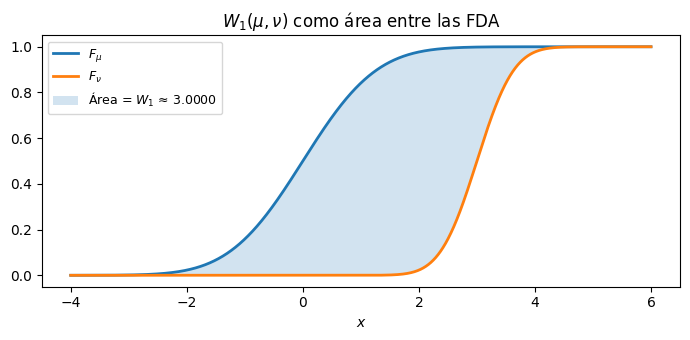

In [ ]:
# @title
# W1 via pseudoinversas
W1_formula = np.trapezoid(np.abs(F_nu_inv - F_mu_inv), t_grid)

# W1 via area entre las FDA
x_grid = np.linspace(-4, 6, 10000)
F_mu_x = norm.cdf(x_grid, mu_mean, mu_std)
F_nu_x = norm.cdf(x_grid, nu_mean, nu_std)
W1_area = np.trapezoid(np.abs(F_mu_x - F_nu_x), x_grid)

print(f"W_1 via pseudoinversas: {W1_formula:.6f}")
print(f"W_1 via área entre FDA: {W1_area:.6f}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x_grid, F_mu_x, lw=2, label=r"$F_\mu$")
ax.plot(x_grid, F_nu_x, lw=2, label=r"$F_\nu$")
ax.fill_between(x_grid, F_mu_x, F_nu_x, alpha=0.2,
                label=f"Área = $W_1$ ≈ {W1_area:.4f}")
ax.set_xlabel("$x$")
ax.set_title(r"$W_1(\mu,\nu)$ como área entre las FDA")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Costos convexos generales y la fórmula del costo óptimo para medidas discretas

La Proposición 8.4.4 vale para cualquier $h$ convexa, no sólo potencias: el costo óptimo es
$\int_0^1 h\bigl(F_\nu^{[-1]}(t)-F_\mu^{[-1]}(t)\bigr)\,dt$.
Para medidas discretas con pesos desiguales esta integral se calcula **exactamente**: el integrando es constante en cada tramo donde ninguna de las dos pseudoinversas salta, y esos tramos son precisamente las entradas no nulas de $\gamma_{\mathrm{mon}}$. Comparamos con el LP (`ot.emd`) para tres costos convexos distintos.


In [ ]:
# @title
rng = np.random.default_rng(0)
n, m = 6, 9
x = np.sort(rng.uniform(-2, 2, n));  a = rng.dirichlet(np.ones(n))
y = np.sort(rng.uniform(-1, 4, m));  b = rng.dirichlet(np.ones(m))

G_mon = plan_comonotono(x, a, y, b)
D = x[:, None] - y[None, :]

for nombre, h in {"z^2": lambda z: z**2, "|z|^3": lambda z: np.abs(z)**3,
                  "cosh(z)": np.cosh, "|z|^{1.5}": lambda z: np.abs(z)**1.5}.items():
    C = h(-D)
    costo_formula = np.sum(G_mon * C)        # = int_0^1 h(F_nu^{-1} - F_mu^{-1}) dt, exacto
    costo_lp      = np.sum(ot.emd(a, b, C) * C)
    print(f"h(z) = {nombre:9s}  fórmula: {costo_formula:.8f}   LP: {costo_lp:.8f}   "
          f"dif: {abs(costo_formula-costo_lp):.1e}")


## 7. Costos con $\partial^2c/\partial x\partial y>0$: el plan antimonótono

El Teorema de optimalidad del mapa monótono cubre los costos $h(y-x)$ con $h$ estrictamente convexa y los costos $C^2$ con $\partial^2c/\partial x\partial y<0$. Si la derivada cruzada es **positiva** (por ejemplo $c(x,y)=xy$, o $c(x,y)=-|x-y|^2$, que corresponde a *maximizar* el costo cuadrático), el mismo argumento de monotonía cíclica de dos puntos da la conclusión opuesta: el plan óptimo es el **antimonótono**, que empareja los cuantiles de $\mu$ con los cuantiles de $\nu$ en orden inverso, $F_\mu^{[-1]}(t)\leftrightarrow F_\nu^{[-1]}(1-t)$ (Ejercicio 8.4). Lo verificamos con POT.

In [ ]:
# @title
import numpy as np, ot, matplotlib.pyplot as plt
rng = np.random.default_rng(3)
n = 200
xs = np.sort(rng.normal(0, 1, n)); ys = np.sort(rng.exponential(1, n))
a = b = np.ones(n)/n
for nombre, C in [(r"c = |x-y|^2", (xs[:, None]-ys[None, :])**2), (r"c = x y", xs[:, None]*ys[None, :]), (r"c = -|x-y|^2", -(xs[:, None]-ys[None, :])**2)]:
    pi = ot.emd(a, b, C)
    sigma = np.argmax(pi, axis=1)                 # con masas iguales el plan es una permutación
    mon = np.all(sigma == np.arange(n)); anti = np.all(sigma == np.arange(n)[::-1])
    print(f"{nombre:>14}: plan monótono = {mon},  plan antimonótono = {anti}")

## Ejercicios computacionales

Los enunciados siguientes figuran también en la sección de ejercicios del Capítulo 8 de las notas.

1. **Mapas monótonos explícitos.** Calcular numéricamente $T_{\mathrm{mon}}$ para $\mu=\mathcal L^1\lfloor_{[0,1]}$ y $\nu$ exponencial, para $\mu$ uniforme y $\nu=\frac13\delta_0+\frac23\delta_1$, y para $\mu=\frac12(\delta_0+\delta_1)$ y $\nu$ uniforme, y comparar con las fórmulas del Ejercicio 8.1. En el último caso, verificar que el plan comonótono **no** está inducido por un mapa y describirlo.

2. **Dominancia estocástica.** Para pares $(\mu,\nu)$ de muestras, verificar numéricamente la equivalencia entre $F_\mu\ge F_\nu$ y $T_{\mathrm{mon}}\ge\mathrm{id}$ (Ejercicio 8.3): graficar ambas condiciones para $\mu=N(0,1)$ y $\nu=N(m,\sigma^2)$ con varios $(m,\sigma)$, y hallar la región del plano $(m,\sigma)$ donde valen.

3. **Cotas de Fréchet–Hoeffding.** Para $\mu$, $\nu$ discretas con $n$ átomos, calcular la función de distribución conjunta $H(x,y)$ de varios planes (el comonótono, el antimonótono, el producto y planes aleatorios) y verificar las cotas $\max\{F_\mu+F_\nu-1,0\}\le H\le\min\{F_\mu,F_\nu\}$ del Ejercicio 7.2, con igualdad en las cotas para los planes extremos.

4. **Costos cóncavos.** Con $\mu=\frac12(\delta_0+\delta_1)$ y $\nu=\frac12(\delta_1+\delta_2)$, calcular el plan óptimo de $|x-y|^p$ para $p\in\{0{,}25,\,0{,}5,\,1,\,2\}$ y determinar en qué $p$ deja de ser óptimo el plan monótono. Repetir con dos densidades continuas que se superpongan y medir la masa que el plan óptimo deja en la diagonal como función de $p$ (Ejercicio 8.5).

5. **La fórmula del área y $p>1$.** Verificar numéricamente que $W_1(\mu,\nu)=\int|F_\mu-F_\nu|\,dx$ para muestras de distintas distribuciones, y que en cambio $W_2^2\ne\int|F_\mu-F_\nu|^2\,dx$ (Ejercicio 10.5). Explicar la diferencia geométricamente con las figuras de la Sección 6.